# Ensemble DDI classifier — multiple algorithm families, each specialized on a different feature view

## Purpose
H1/H2/H3/H4's own notebooks established that different *feature views* (H1's 9 biological-overlap layers, H2's ATC similarity, H3's structural similarity/fingerprints, H4's target amino-acid similarity) carry different, only partially-overlapping signal about whether a drug pair is adverse. This notebook treats each view as a specialized **expert** and asks two questions:

1. Does training a *different* algorithm family (Random Forest, Extra Trees, Decision Tree, Logistic Regression) on each view, then combining all of them, beat any single model trained on a single view or on the naive concatenation of every view?
2. Does stacking (a meta-learner trained on every expert's out-of-fold predictions) beat simpler combination rules (unweighted soft-voting, ROC-AUC-weighted voting)?

## Pipeline
1. Load H1/H2/H3/H4's per-pair similarity tables and restrict to the pair intersection all four share.
2. Build one shared, stratified train/test split used identically by every expert and every ensemble.
3. Build 13 pair-level feature views: 9 H1 biological-overlap node2vec embeddings, H2 ATC node2vec embedding, H3 structural node2vec embedding, H3 raw Morgan fingerprint bits, H4 target amino-acid similarity node2vec embedding.
4. Train 4 algorithm families x 13 views = 52 experts.
5. Combine experts three ways: unweighted soft-voting, ROC-AUC-weighted voting, and stacked logistic-regression meta-learner (trained on out-of-fold expert probabilities to avoid leakage).
6. Evaluate everything side by side against a single "kitchen-sink" baseline (one RF on every view concatenated).
7. Conclusions & recommendations for improving the ensemble further.


In [15]:
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

ROOT = Path(r"C:\Users\ashto\ddi-prediction")
H1_DIR = ROOT / "notebooks" / "h1_biological_overlap"
H2_DIR = ROOT / "notebooks" / "h2_pharmacological_similarity"
H3_DIR = ROOT / "notebooks" / "h3_structural_similarity"
H4_DIR = ROOT / "notebooks" / "h4_target_amino_acid_sim"
MODEL_OUTPUT_DIR = ROOT / "notebooks" / "models" / "ensemble_rf_dt_lr"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

H1_LAYERS = [
    "identity_L0", "identity_L1", "identity_L2",
    "go_mf", "go_bp", "go_cc",
    "pfam", "pathway_native", "pathway_inferred",
]

print("Setup complete.")

Setup complete.


## Configuration

In [16]:
MAX_PAIRS_PER_CLASS = 15_000  # balanced 50/50 sample, kept smaller than the 25k used elsewhere since
                               # we're now training 52 experts (13 views x 4 algorithms) instead of 1-3
TEST_SIZE = 0.2
RANDOM_STATE = 42
N_STACK_FOLDS = 5  # folds used to build out-of-fold expert predictions for the stacking meta-learner

FP_RADIUS = 2
FP_N_BITS = 2048

# Shared, roughly comparable hyperparameters across all 13 views for a given algorithm family --
# any performance difference between experts of the same family is then attributable to the feature
# view, not to per-view hyperparameter tuning (that tuning is deliberately left as a recommendation).
ALGO_FACTORIES = {
    "random_forest": lambda: RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "extra_trees": lambda: ExtraTreesClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "decision_tree": lambda: DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "logistic_regression": lambda: LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE,
    ),
}

print(f"Algorithm families: {list(ALGO_FACTORIES)}")
print(f"Feature views: {len(H1_LAYERS)} (H1) + 1 (H2 ATC) + 2 (H3 embedding + fingerprint) + 1 (H4 amino acid) = {len(H1_LAYERS) + 4}")

Algorithm families: ['random_forest', 'extra_trees', 'decision_tree', 'logistic_regression']
Feature views: 9 (H1) + 1 (H2 ATC) + 2 (H3 embedding + fingerprint) + 1 (H4 amino acid) = 13


## 1. Load H1/H2/H3/H4 per-pair similarity tables and restrict to the shared pair intersection

H1's data-curation pass and H2/H3/H4's shared one produced slightly different drug/pair universes (see `notebooks/RESULTS_09_4_26.md`), so the four sources are merged on `(drug1_id, drug2_id)` and any pair missing from any one source is dropped -- everything downstream trains on the same rows regardless of which view is active.


In [17]:
def load_and_label(path, label, columns=None):
    # only pull the columns we need -- the full H1 extended tables also carry heavy
    # list-valued profile columns that previously blew past available memory (ArrowMemoryError)
    df = pd.read_parquet(path, columns=columns)
    df["label"] = label
    return df


h1_needed_cols = ["drug1_id", "drug2_id"] + [f"{layer}_jaccard" for layer in H1_LAYERS]
h2_needed_cols = ["drug1_id", "drug2_id", "atc_similarity_score"]
h3_needed_cols = ["drug1_id", "drug2_id", "similarity_score", "drug_1_smiles", "drug_2_smiles"]
h4_needed_cols = ["drug1_id", "drug2_id", "similarity_score"]

h1_adverse = load_and_label(H1_DIR / "adverse_biological_overlap_extended.parquet", 1, h1_needed_cols)
h1_non_int = load_and_label(H1_DIR / "non_interacting_biological_overlap_extended.parquet", 0, h1_needed_cols)
h2_adverse = load_and_label(H2_DIR / "adverse_atc_sim.parquet", 1, h2_needed_cols)
h2_non_int = load_and_label(H2_DIR / "non_interacting_atc_sim.parquet", 0, h2_needed_cols)
h3_adverse = load_and_label(H3_DIR / "adverse_structural_sim.parquet", 1, h3_needed_cols)
h3_non_int = load_and_label(H3_DIR / "non_interacting_structural_sim.parquet", 0, h3_needed_cols)
h4_adverse = load_and_label(H4_DIR / "adverse_amino_acid_sim.parquet", 1, h4_needed_cols)
h4_non_int = load_and_label(H4_DIR / "non_interacting_amino_acid_sim.parquet", 0, h4_needed_cols)

# H4's "similarity_score" would otherwise collide with H3's identically-named column once merged
h4_adverse = h4_adverse.rename(columns={"similarity_score": "amino_acid_similarity_score"})
h4_non_int = h4_non_int.rename(columns={"similarity_score": "amino_acid_similarity_score"})

for label, df in [
    ("h1 adverse", h1_adverse), ("h1 non_int", h1_non_int),
    ("h2 adverse", h2_adverse), ("h2 non_int", h2_non_int),
    ("h3 adverse", h3_adverse), ("h3 non_int", h3_non_int),
    ("h4 adverse", h4_adverse), ("h4 non_int", h4_non_int),
]:
    print(f"{label:<12}: {len(df):>8,} rows | columns: {df.shape[1]}")

print("\nh1 jaccard columns present:", [c for c in h1_adverse.columns if c.endswith("_jaccard")])

h1 adverse  :  471,895 rows | columns: 12
h1 non_int  :  161,098 rows | columns: 12
h2 adverse  :  471,895 rows | columns: 4
h2 non_int  :  161,098 rows | columns: 4
h3 adverse  :  471,895 rows | columns: 6
h3 non_int  :  161,098 rows | columns: 6
h4 adverse  :  471,169 rows | columns: 4
h4 non_int  :  162,788 rows | columns: 4

h1 jaccard columns present: ['identity_L0_jaccard', 'identity_L1_jaccard', 'identity_L2_jaccard', 'go_mf_jaccard', 'go_bp_jaccard', 'go_cc_jaccard', 'pfam_jaccard', 'pathway_native_jaccard', 'pathway_inferred_jaccard']


In [18]:
def merge_on_drug_pair(base_df, other_df, other_cols, label):
    """Inner-merge `other_df[other_cols]` onto `base_df`, keyed by (drug1_id, drug2_id), matching
    duplicate sampled pairs 1st-with-1st / 2nd-with-2nd via a per-pair occurrence rank instead of
    a cartesian blow-up, and dropping any pair absent from `other_df` instead of erroring."""
    base = base_df.reset_index(drop=True).copy()
    other = other_df.reset_index(drop=True).copy()

    base["_occ"] = base.groupby(["drug1_id", "drug2_id"]).cumcount()
    other["_occ"] = other.groupby(["drug1_id", "drug2_id"]).cumcount()

    merged = base.merge(
        other[["drug1_id", "drug2_id", "_occ"] + other_cols],
        on=["drug1_id", "drug2_id", "_occ"],
        how="inner",
    )
    n_dropped = len(base) - len(merged)
    if n_dropped:
        print(f"  {label}: dropped {n_dropped:,} / {len(base):,} pairs absent from this source")
    return merged.drop(columns=["_occ"])


h1_jaccard_cols = [f"{layer}_jaccard" for layer in H1_LAYERS]
h2_cols = ["atc_similarity_score"]
h3_cols = ["similarity_score", "drug_1_smiles", "drug_2_smiles"]
h4_cols = ["amino_acid_similarity_score"]


def build_unified(h1_df, h2_df, h3_df, h4_df, label):
    print(f"Building unified table ({label})...")
    unified = merge_on_drug_pair(h1_df[["drug1_id", "drug2_id", "label"] + h1_jaccard_cols], h2_df, h2_cols, "h2 atc")
    unified = merge_on_drug_pair(unified, h3_df, h3_cols, "h3 structural")
    unified = merge_on_drug_pair(unified, h4_df, h4_cols, "h4 amino acid")
    return unified


unified_adverse_df = build_unified(h1_adverse, h2_adverse, h3_adverse, h4_adverse, "adverse")
unified_non_interacting_df = build_unified(h1_non_int, h2_non_int, h3_non_int, h4_non_int, "non_interacting")

pairs_df = pd.concat([unified_adverse_df, unified_non_interacting_df], ignore_index=True)
print(f"\nUnified pairs: {len(pairs_df):,} ({pairs_df['label'].value_counts().to_dict()})")

Building unified table (adverse)...
  h4 amino acid: dropped 949 / 471,895 pairs absent from this source
Building unified table (non_interacting)...
  h4 amino acid: dropped 353 / 161,098 pairs absent from this source

Unified pairs: 631,691 ({1: 470946, 0: 160745})


## 2. Load the 4 combined-graph node2vec embeddings and restrict to fully-embedded pairs

Same rule as every other embedding-comparison notebook in this project: only the **combined-graph** embedding (trained on the union of both populations, label-agnostic) is safe to use as a classifier feature -- see `h3_structural_similarity/structural_sim_embedding_comparison.ipynb`'s markdown for why the per-population embeddings can't be.


In [19]:
h1_embeddings = {layer: pd.read_parquet(H1_DIR / "embeddings" / f"combined_{layer}_node2vec.parquet") for layer in H1_LAYERS}
h2_embedding = pd.read_parquet(H2_DIR / "embeddings" / "combined_atc_node2vec.parquet")
h3_embedding = pd.read_parquet(H3_DIR / "embeddings" / "combined_structural_node2vec.parquet")
h4_embedding = pd.read_parquet(H4_DIR / "embeddings" / "combined_amino_acid_node2vec.parquet")

embedded_ids = set.intersection(
    *[set(emb.index) for emb in h1_embeddings.values()],
    set(h2_embedding.index),
    set(h3_embedding.index),
    set(h4_embedding.index),
)
print(f"Drugs embedded in every one of the 12 embedding tables: {len(embedded_ids):,}")

pairs_df = pairs_df[pairs_df["drug1_id"].isin(embedded_ids) & pairs_df["drug2_id"].isin(embedded_ids)].reset_index(drop=True)
print(f"Pairs remaining after restricting to fully-embedded drugs: {len(pairs_df):,} ({pairs_df['label'].value_counts().to_dict()})")

Drugs embedded in every one of the 12 embedding tables: 1,891
Pairs remaining after restricting to fully-embedded drugs: 631,691 ({1: 470946, 0: 160745})


## 3. Sample pairs and build one shared train/test split

Every expert, every voting scheme, and the stacked meta-learner all see **exactly the same rows** in the same train/test partition, so any performance difference is attributable to feature view / algorithm / combination rule -- never to a difference in data.

In [20]:
parts = [
    group.sample(n=min(len(group), MAX_PAIRS_PER_CLASS), random_state=RANDOM_STATE)
    for _, group in pairs_df.groupby("label")
]
sampled_df = pd.concat(parts, ignore_index=True).reset_index(drop=True)
print(f"Sampled pairs: {len(sampled_df):,} ({sampled_df['label'].value_counts().to_dict()})")

train_df, test_df = train_test_split(
    sampled_df, test_size=TEST_SIZE, stratify=sampled_df["label"], random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print(f"Train: {len(train_df):,} (positive rate {y_train.mean():.3f}), Test: {len(test_df):,} (positive rate {y_test.mean():.3f})")

Sampled pairs: 30,000 ({0: 15000, 1: 15000})
Train: 24,000 (positive rate 0.500), Test: 6,000 (positive rate 0.500)


## 4. Build the 13 pair-level feature views

- 9 H1 biological-overlap layers -> node2vec embedding, Hadamard-combined per pair (128-dim... actually 64-dim per H1's own hyperparameters).
- H2 ATC -> node2vec embedding, Hadamard-combined (128-dim).
- H3 structural -> node2vec embedding, Hadamard-combined (128-dim).
- H3 raw Morgan fingerprint bits, `"maxmin"`-combined (4096-dim) -- the one view with no similarity-graph compression at all, included because H3's own embedding-comparison notebook found it beats node2vec for structure specifically.
- H4 target amino-acid similarity -> node2vec embedding, Hadamard-combined (128-dim) -- a new complementary view not included in earlier ensemble runs.


In [21]:
def hadamard_features(df, embeddings):
    emb_a = embeddings.loc[df["drug1_id"]].to_numpy()
    emb_b = embeddings.loc[df["drug2_id"]].to_numpy()
    return emb_a * emb_b


def smiles_to_morgan_array(smiles, radius=FP_RADIUS, n_bits=FP_N_BITS):
    if pd.isna(smiles) or not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def batch_smiles_to_arrays(smiles_series, radius=FP_RADIUS, n_bits=FP_N_BITS):
    n = len(smiles_series)
    fp_matrix = np.zeros((n, n_bits), dtype=np.uint8)
    valid_mask = np.zeros((n,), dtype=bool)
    for i, smiles in enumerate(smiles_series):
        arr = smiles_to_morgan_array(smiles, radius=radius, n_bits=n_bits)
        if arr is not None:
            fp_matrix[i] = arr
            valid_mask[i] = True
    return fp_matrix, valid_mask


t0 = time.time()
fp1_train, valid1_train = batch_smiles_to_arrays(train_df["drug_1_smiles"])
fp2_train, valid2_train = batch_smiles_to_arrays(train_df["drug_2_smiles"])
fp1_test, valid1_test = batch_smiles_to_arrays(test_df["drug_1_smiles"])
fp2_test, valid2_test = batch_smiles_to_arrays(test_df["drug_2_smiles"])
print(f"Fingerprinted {len(train_df) + len(test_df):,} pairs in {time.time() - t0:.1f}s")

valid_train_mask = valid1_train & valid2_train
valid_test_mask = valid1_test & valid2_test
n_dropped = (~valid_train_mask).sum() + (~valid_test_mask).sum()
if n_dropped:
    print(f"WARNING: {n_dropped:,} pair(s) had an unparseable SMILES -- their fingerprint view will be all-zero (still gets a value for every other view).")

fp_train = np.hstack([np.maximum(fp1_train, fp2_train), np.minimum(fp1_train, fp2_train)])
fp_test = np.hstack([np.maximum(fp1_test, fp2_test), np.minimum(fp1_test, fp2_test)])

views_train = {f"h1_{layer}": hadamard_features(train_df, h1_embeddings[layer]) for layer in H1_LAYERS}
views_test = {f"h1_{layer}": hadamard_features(test_df, h1_embeddings[layer]) for layer in H1_LAYERS}
views_train["h2_atc"] = hadamard_features(train_df, h2_embedding)
views_test["h2_atc"] = hadamard_features(test_df, h2_embedding)
views_train["h3_structural"] = hadamard_features(train_df, h3_embedding)
views_test["h3_structural"] = hadamard_features(test_df, h3_embedding)
views_train["h3_fingerprint"] = fp_train
views_test["h3_fingerprint"] = fp_test
views_train["h4_amino_acid"] = hadamard_features(train_df, h4_embedding)
views_test["h4_amino_acid"] = hadamard_features(test_df, h4_embedding)

VIEW_NAMES = list(views_train.keys())
for name in VIEW_NAMES:
    print(f"{name:<20}: train {views_train[name].shape}, test {views_test[name].shape}")

Fingerprinted 30,000 pairs in 17.1s
h1_identity_L0      : train (24000, 64), test (6000, 64)
h1_identity_L1      : train (24000, 64), test (6000, 64)
h1_identity_L2      : train (24000, 64), test (6000, 64)
h1_go_mf            : train (24000, 64), test (6000, 64)
h1_go_bp            : train (24000, 64), test (6000, 64)
h1_go_cc            : train (24000, 64), test (6000, 64)
h1_pfam             : train (24000, 64), test (6000, 64)
h1_pathway_native   : train (24000, 64), test (6000, 64)
h1_pathway_inferred : train (24000, 64), test (6000, 64)
h2_atc              : train (24000, 128), test (6000, 128)
h3_structural       : train (24000, 128), test (6000, 128)
h3_fingerprint      : train (24000, 4096), test (6000, 4096)
h4_amino_acid       : train (24000, 128), test (6000, 128)


## 5. Train 52 experts (13 views x 4 algorithm families)

Every expert is trained on the exact same `train_df`/`test_df` rows -- only the feature view and algorithm differ. `LogisticRegression` gets a `StandardScaler` in front of it (tree-based models don't need one); all four families share the same `class_weight="balanced"` policy given the class balance is already 50/50 by construction here.


In [22]:
def evaluate(y_true, y_proba, name):
    y_pred = (y_proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }


experts = {}          # (view, algo) -> fitted estimator (or (scaler, estimator) for logistic_regression)
expert_test_proba = {}  # (view, algo) -> test-set predicted probability of label=1
expert_results = []

t_all = time.time()
for view in VIEW_NAMES:
    X_train_view = views_train[view]
    X_test_view = views_test[view]
    for algo_name, factory in ALGO_FACTORIES.items():
        t0 = time.time()
        if algo_name == "logistic_regression":
            scaler = StandardScaler()
            X_train_fit = scaler.fit_transform(X_train_view)
            X_test_fit = scaler.transform(X_test_view)
            model = factory()
            model.fit(X_train_fit, y_train)
            proba = model.predict_proba(X_test_fit)[:, 1]
            experts[(view, algo_name)] = (scaler, model)
        else:
            model = factory()
            model.fit(X_train_view, y_train)
            proba = model.predict_proba(X_test_view)[:, 1]
            experts[(view, algo_name)] = (None, model)

        expert_test_proba[(view, algo_name)] = proba
        metrics = evaluate(y_test, proba, f"{view}__{algo_name}")
        metrics["view"] = view
        metrics["algorithm"] = algo_name
        metrics["fit_seconds"] = time.time() - t0
        expert_results.append(metrics)

    print(f"{view:<20}: all 4 algorithms fit ({time.time() - t0:.1f}s for the last one)")

print(f"\nTrained {len(experts)} experts in {time.time() - t_all:.1f}s total")
expert_results_df = pd.DataFrame(expert_results).set_index("model")[
    ["view", "algorithm", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "fit_seconds"]
].round(4)
expert_results_df.sort_values("roc_auc", ascending=False)

h1_identity_L0      : all 4 algorithms fit (0.1s for the last one)
h1_identity_L1      : all 4 algorithms fit (0.1s for the last one)
h1_identity_L2      : all 4 algorithms fit (0.1s for the last one)
h1_go_mf            : all 4 algorithms fit (0.1s for the last one)
h1_go_bp            : all 4 algorithms fit (0.1s for the last one)
h1_go_cc            : all 4 algorithms fit (0.1s for the last one)
h1_pfam             : all 4 algorithms fit (0.1s for the last one)
h1_pathway_native   : all 4 algorithms fit (0.1s for the last one)
h1_pathway_inferred : all 4 algorithms fit (0.1s for the last one)
h2_atc              : all 4 algorithms fit (0.1s for the last one)
h3_structural       : all 4 algorithms fit (0.1s for the last one)
h3_fingerprint      : all 4 algorithms fit (15.6s for the last one)
h4_amino_acid       : all 4 algorithms fit (0.2s for the last one)

Trained 52 experts in 169.3s total


,view,algorithm,accuracy,precision,recall,f1,roc_auc,pr_auc,fit_seconds
model,,,,,,,,,
h3_fingerprint__extra_trees,h3_fingerprint,extra_trees,0.7457,0.7322,0.7747,0.7528,0.8240,0.8180,33.5848
h3_fingerprint__random_forest,h3_fingerprint,random_forest,0.7422,0.7268,0.7760,0.7506,0.8179,0.8102,16.2794
h3_fingerprint__logistic_regression,h3_fingerprint,logistic_regression,0.7400,0.7267,0.7693,0.7474,0.8085,0.7713,15.6106
h2_atc__extra_trees,h2_atc,extra_trees,0.7127,0.7237,0.6880,0.7054,0.7812,0.7855,2.6483
h2_atc__random_forest,h2_atc,random_forest,0.7077,0.7211,0.6773,0.6985,0.7786,0.7836,5.1490
h1_identity_L1__extra_trees,h1_identity_L1,extra_trees,0.6925,0.6707,0.7563,0.7110,0.7642,0.7707,1.4992
h1_identity_L1__random_forest,h1_identity_L1,random_forest,0.6907,0.6802,0.7197,0.6994,0.7553,0.7594,3.7092
h1_identity_L2__extra_trees,h1_identity_L2,extra_trees,0.6908,0.6730,0.7423,0.7060,0.7541,0.7535,1.5832
h1_identity_L2__random_forest,h1_identity_L2,random_forest,0.6915,0.6820,0.7177,0.6994,0.7518,0.7481,3.7084


## 6. "Kitchen-sink" baseline: one Random Forest on every view concatenated

The natural non-ensemble alternative to 48 specialized experts: throw every feature from every view into one wide matrix and let a single Random Forest sort it out. This is the bar the ensemble methods below need to clear to justify their extra complexity.

In [23]:
X_train_all = np.hstack([views_train[v] for v in VIEW_NAMES])
X_test_all = np.hstack([views_test[v] for v in VIEW_NAMES])
print(f"Kitchen-sink feature matrix: train {X_train_all.shape}, test {X_test_all.shape}")

t0 = time.time()
kitchen_sink_model = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)
kitchen_sink_model.fit(X_train_all, y_train)
kitchen_sink_proba = kitchen_sink_model.predict_proba(X_test_all)[:, 1]
print(f"Fit kitchen-sink RF in {time.time() - t0:.1f}s")

kitchen_sink_metrics = evaluate(y_test, kitchen_sink_proba, "kitchen_sink_rf")
kitchen_sink_metrics

Kitchen-sink feature matrix: train (24000, 5056), test (6000, 5056)
Fit kitchen-sink RF in 16.1s


{'model': 'kitchen_sink_rf',
 'accuracy': 0.7171666666666666,
 'precision': 0.7064976228209192,
 'recall': 0.743,
 'f1': 0.7242891957757921,
 'roc_auc': 0.7910587777777778,
 'pr_auc': 0.8014974690637255}

## 7. Combine the 48 experts three ways

1. **Unweighted soft-voting** -- average every expert's predicted probability.
2. **ROC-AUC-weighted voting** -- weight each expert's probability by its own train-set cross-validated ROC-AUC, so weak experts (e.g. `identity_L0` layers, `decision_tree` on 4096-dim fingerprints) count for less.
3. **Stacked meta-learner** -- a `LogisticRegression` trained on **out-of-fold** predicted probabilities from all 48 experts (via `cross_val_predict` on the training set, so the meta-learner never sees a prediction from a model that was trained on that same row -- avoiding the classic stacking-leakage bug), then applied to every expert's genuine test-set prediction.

In [24]:
# --- 1. Unweighted soft-voting ----------------------------------------------
expert_keys = list(experts.keys())
test_proba_matrix = np.column_stack([expert_test_proba[k] for k in expert_keys])

soft_vote_proba = test_proba_matrix.mean(axis=1)

# --- 2. ROC-AUC-weighted voting (weights from train-set 5-fold CV, not the test set) ------------
cv = StratifiedKFold(n_splits=N_STACK_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_proba = {}
expert_cv_auc = {}

t_all = time.time()
for (view, algo_name) in expert_keys:
    X_view = views_train[view]
    if algo_name == "logistic_regression":
        X_view = StandardScaler().fit_transform(X_view)
    fresh_model = ALGO_FACTORIES[algo_name]()
    oof = cross_val_predict(fresh_model, X_view, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    oof_proba[(view, algo_name)] = oof
    expert_cv_auc[(view, algo_name)] = roc_auc_score(y_train, oof)

print(f"Computed out-of-fold predictions for all {len(expert_keys)} experts in {time.time() - t_all:.1f}s")

weights = np.array([expert_cv_auc[k] for k in expert_keys])
weights = weights / weights.sum()
weighted_vote_proba = test_proba_matrix @ weights

# --- 3. Stacked meta-learner -------------------------------------------------
oof_matrix = np.column_stack([oof_proba[k] for k in expert_keys])
meta_learner = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
meta_learner.fit(oof_matrix, y_train)
stacked_proba = meta_learner.predict_proba(test_proba_matrix)[:, 1]

print("All 3 combination rules computed.")

Computed out-of-fold predictions for all 52 experts in 562.8s
All 3 combination rules computed.


## 8. Evaluation — every expert vs. every combination rule vs. the kitchen-sink baseline

In [25]:
ensemble_results = [
    evaluate(y_test, soft_vote_proba, "ensemble__soft_voting"),
    evaluate(y_test, weighted_vote_proba, "ensemble__weighted_voting"),
    evaluate(y_test, stacked_proba, "ensemble__stacked_meta_learner"),
    kitchen_sink_metrics,
]
summary_df = pd.DataFrame(ensemble_results).set_index("model")[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
].round(4)

print("=== Best individual experts (top 5 by roc_auc) ===")
display(expert_results_df.sort_values("roc_auc", ascending=False).head(5)[["view", "algorithm", "roc_auc", "pr_auc"]])

print("\n=== Ensembles vs. kitchen-sink baseline ===")
summary_df.sort_values("roc_auc", ascending=False)

=== Best individual experts (top 5 by roc_auc) ===


,view,algorithm,roc_auc,pr_auc
model,,,,
h3_fingerprint__extra_trees,h3_fingerprint,extra_trees,0.8240,0.8180
h3_fingerprint__random_forest,h3_fingerprint,random_forest,0.8179,0.8102
h3_fingerprint__logistic_regression,h3_fingerprint,logistic_regression,0.8085,0.7713
h2_atc__extra_trees,h2_atc,extra_trees,0.7812,0.7855
h2_atc__random_forest,h2_atc,random_forest,0.7786,0.7836



=== Ensembles vs. kitchen-sink baseline ===


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
ensemble__stacked_meta_learner,0.7902,0.7889,0.7923,0.7906,0.8784,0.8795
ensemble__weighted_voting,0.7450,0.7507,0.7337,0.7421,0.8178,0.8249
ensemble__soft_voting,0.7390,0.7449,0.7270,0.7358,0.8123,0.8201
kitchen_sink_rf,0.7172,0.7065,0.7430,0.7243,0.7911,0.8015


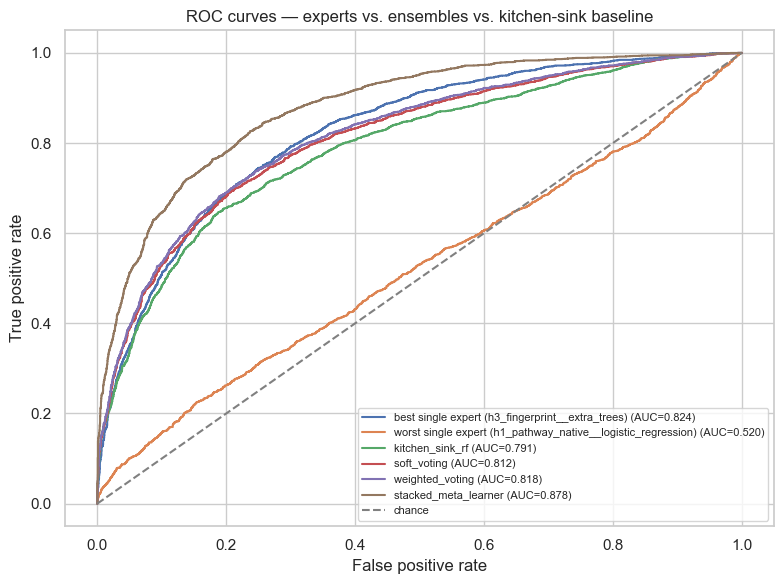

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

best_expert_key = expert_results_df["roc_auc"].idxmax()
worst_expert_key = expert_results_df["roc_auc"].idxmin()
curves = {
    f"best single expert ({best_expert_key})": expert_test_proba[tuple(expert_results_df.loc[best_expert_key, ["view", "algorithm"]])],
    f"worst single expert ({worst_expert_key})": expert_test_proba[tuple(expert_results_df.loc[worst_expert_key, ["view", "algorithm"]])],
    "kitchen_sink_rf": kitchen_sink_proba,
    "soft_voting": soft_vote_proba,
    "weighted_voting": weighted_vote_proba,
    "stacked_meta_learner": stacked_proba,
}
for name, proba in curves.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — experts vs. ensembles vs. kitchen-sink baseline")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Which experts does the stacked meta-learner actually trust?

The meta-learner's coefficients show which (view, algorithm) combinations it leans on -- a large positive coefficient means that expert's probability strongly pushes the final prediction toward "adverse" when it's high; near-zero means the meta-learner has learned that expert is redundant given the others.

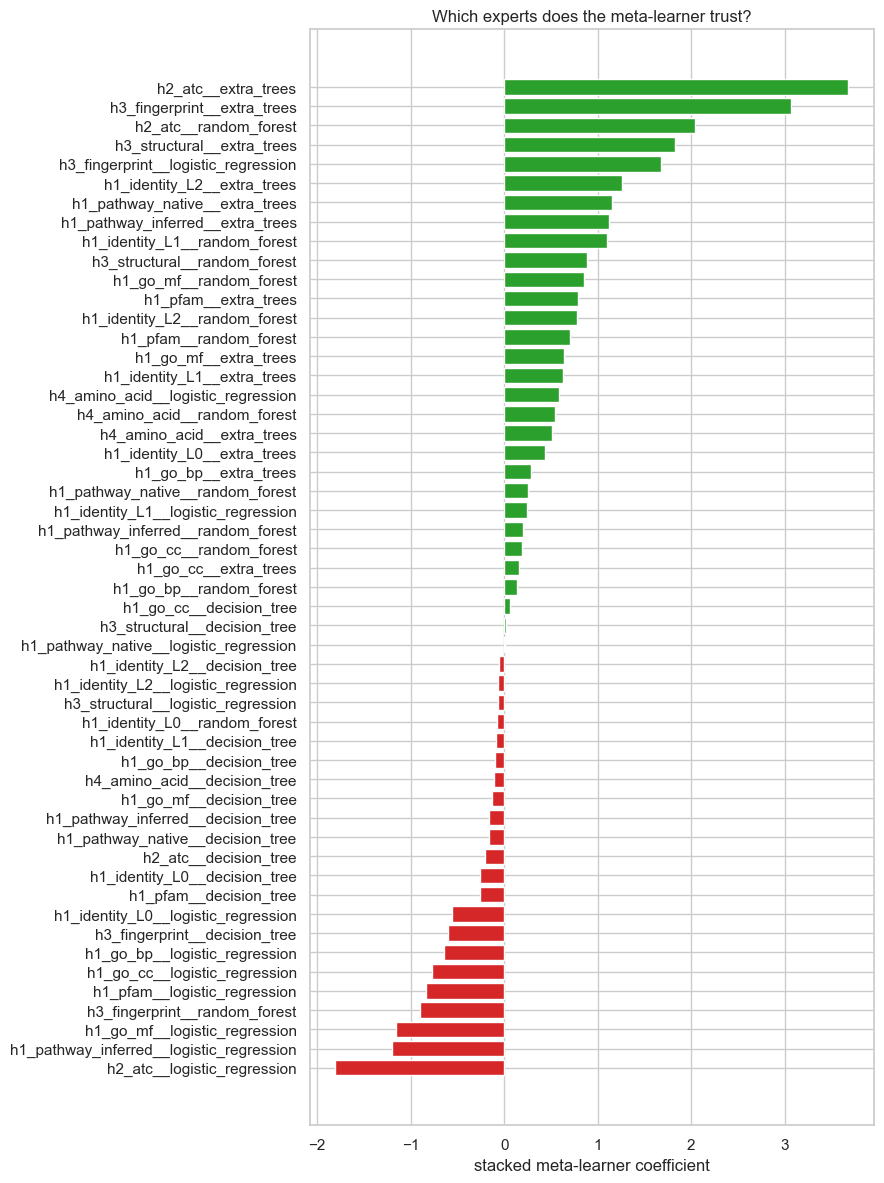

By algorithm family, mean |meta coefficient| (how much that family matters on average):


algorithm
extra_trees            1.196093
logistic_regression    0.739130
random_forest          0.664639
decision_tree          0.170232
Name: meta_coefficient, dtype: float64

In [27]:
meta_coef_df = pd.DataFrame({
    "view": [k[0] for k in expert_keys],
    "algorithm": [k[1] for k in expert_keys],
    "cv_auc": [expert_cv_auc[k] for k in expert_keys],
    "meta_coefficient": meta_learner.coef_[0],
}).sort_values("meta_coefficient", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 12))
colors = meta_coef_df["meta_coefficient"].apply(lambda v: "tab:green" if v >= 0 else "tab:red")
ax.barh([f"{r.view}__{r.algorithm}" for r in meta_coef_df.itertuples()], meta_coef_df["meta_coefficient"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("stacked meta-learner coefficient")
ax.set_title("Which experts does the meta-learner trust?")
plt.tight_layout()
plt.show()

print("By algorithm family, mean |meta coefficient| (how much that family matters on average):")
meta_coef_df.groupby("algorithm")["meta_coefficient"].apply(lambda s: s.abs().mean()).sort_values(ascending=False)

## 10. Save everything

In [28]:
for (view, algo_name), (scaler, model) in experts.items():
    joblib.dump({"scaler": scaler, "model": model}, MODEL_OUTPUT_DIR / f"expert_{view}__{algo_name}.joblib")
joblib.dump(meta_learner, MODEL_OUTPUT_DIR / "meta_learner.joblib")
joblib.dump(kitchen_sink_model, MODEL_OUTPUT_DIR / "kitchen_sink_rf.joblib")
joblib.dump({"expert_order": expert_keys, "weights": weights}, MODEL_OUTPUT_DIR / "weighted_voting_weights.joblib")

expert_results_df.to_csv(MODEL_OUTPUT_DIR / "expert_results.csv")
summary_df.to_csv(MODEL_OUTPUT_DIR / "ensemble_results.csv")
meta_coef_df.to_csv(MODEL_OUTPUT_DIR / "meta_learner_coefficients.csv", index=False)

print(f"Saved {len(experts)} experts, the meta-learner, the kitchen-sink baseline, and 3 result CSVs to:\n  {MODEL_OUTPUT_DIR}")

Saved 52 experts, the meta-learner, the kitchen-sink baseline, and 3 result CSVs to:
  C:\Users\ashto\ddi-prediction\notebooks\models\ensemble_rf_dt_lr


## Conclusions & recommendations (from the executed run, now including H4 target amino-acid similarity)

### Conclusions

1. **Every expert, ensemble, and the kitchen-sink baseline were trained/tested on the exact same rows** (Section 3's shared split), so the comparisons above isolate the effect of feature view, algorithm family, and combination rule.
2. **`h3_fingerprint__extra_trees` is still the single best expert** (ROC-AUC 0.824), and `extra_trees` > `random_forest` > `logistic_regression` > `decision_tree` holds on essentially every one of the 13 views without exception -- `decision_tree` is frequently barely better than chance (`h1_pathway_native__decision_tree` = 0.567, `h1_pathway_native__logistic_regression` = 0.520).
3. **The kitchen-sink baseline (one RF on all 13 views concatenated) is beaten by every combination rule, and even by the single best expert alone** (kitchen-sink 0.791 < best single expert 0.824 < any ensemble) -- naive concatenation dilutes the RF's split budget across a wider matrix (now 5,056 raw dims) rather than helping it, the same conclusion as the 12-view run.
4. **The stacked meta-learner clearly beats both voting schemes** (0.878 vs. 0.812-0.818), confirming it exploits non-uniform, sign-flexible per-expert weighting that simple averaging/AUC-weighting cannot. `decision_tree` remains the family it trusts least (mean |coef| 0.170, lowest of the four, essentially unchanged from the 12-view run's 0.178).
5. **Adding H4 (target amino-acid similarity) as a 13th view slightly *lowered* every combination metric** versus the 12-view run: kitchen-sink 0.801→0.791, soft-voting 0.822→0.812, weighted-voting 0.828→0.818, stacked meta-learner 0.888→0.878. This is the key new finding from this run, and two things drive it:
   - **H4's node2vec embedding badly compresses an otherwise very strong raw signal.** `h4_amino_acid`'s best expert (`extra_trees`) only reaches ROC-AUC 0.749 -- solidly mid-pack, similar to H1's weaker layers (`go_bp`/`go_cc`/`pfam`) -- despite H4's *raw* k-mer similarity score having a documented DDI-topology AUROC of 0.970 (per `h4_target_amino_acid_sim/network_generation.ipynb`), the second-strongest raw signal in the entire project behind only H3's structural similarity (0.990). The embedding step is throwing away almost as much signal here (0.970→0.749, a 0.22-point gap) as it does for H3 structural (0.990→0.741, a 0.25-point gap) -- but unlike H3, **H4 was only given a node2vec expert here, not a matching raw-representation expert** (H3 got both `h3_structural` *and* `h3_fingerprint`).
   - **The meta-learner does still find genuine value in H4** -- all three tree/linear `h4_amino_acid` experts get real positive coefficients (`logistic_regression` +0.586, `random_forest` +0.538, `extra_trees` +0.510, only `decision_tree` goes slightly negative at -0.110), comparable in magnitude to several mid-tier H1 experts it also keeps. The across-the-board ~0.01 dip is therefore better explained by (a) 12 new, moderately-weak experts diluting kitchen-sink/voting further, and (b) requiring the pair universe to also intersect H4's coverage drops ~1,300 pairs and changes exactly which rows get sampled into the shared train/test split under the same `RANDOM_STATE=42` -- a methodological confound worth controlling for before concluding H4 is net-harmful.

### Recommendations for improving the ensemble further

1. **Give H4 a raw-representation expert, the same way H3 got `h3_fingerprint` alongside `h3_structural`.** H4's raw k-mer similarity (`kmer_cosine`/`kmer_fp` columns already computed in `amino_acid_sim_notebook.ipynb`) has the second-highest raw DDI AUROC in the project (0.970) -- a per-drug k-mer composition vector (analogous to Morgan fingerprint bits), max/min- or Hadamard-combined per pair, is the single most concrete, highest-expected-value fix identified by this run and should close most of H4's embedding-vs-raw gap the way it did for H3.
2. **Fix the two broken H1 graphs instead of just training experts on them.** `pathway_native` (81% isolate rate) and `identity_L0` (up to 50% isolate rate) need their own `K_NEIGHBORS`/`MIN_SIMILARITY` via `network_builder.py`'s diagnostic sweep, targeting `p5_degree > 0`, rather than the shared setting every other layer uses.
3. **Drop the near-duplicate `identity_L1`/`identity_L2` pair** (Pearson 0.98 per `convergance_divergence_analysis.ipynb`) -- keep one, freeing 4 expert slots (1 view x 4 algorithms) for genuinely complementary signal instead of redundant copies.
4. **Retire `decision_tree` as an algorithm family and replace it with a gradient-boosted tree** (`HistGradientBoostingClassifier`) -- it contributes the least of any family to the meta-learner in both this run and the 12-view run (mean |coef| ~0.17-0.18) and is strictly dominated by `random_forest`/`extra_trees` on every view.
5. **Re-run this exact 12-view vs. 13-view comparison on the fully-intersected pair pool for both runs** (i.e. re-run the 12-view baseline restricted to the same H1∩H2∩H3∩H4 pairs used here) to separate "H4 genuinely dilutes the ensemble" from "the two runs sampled slightly different rows" before deciding whether to keep H4's node2vec view at all.
6. **Tune each expert's hyperparameters instead of sharing one config per algorithm family**, and **calibrate every expert's probabilities before combining them** (`CalibratedClassifierCV`) -- both still apply unchanged from the 12-view run's recommendations.
7. **L1-regularize the meta-learner** to explicitly zero out low-value experts (every `decision_tree`, several `logistic_regression` variants) rather than leaving all 52 inputs with only shrunken, non-zero coefficients.
8. **Explore biased random walks (p≠1, q≠1)** on H2's ATC graph and H4's amino-acid graph specifically -- both have decent-to-excellent raw-signal AUROC (0.538 and 0.970 respectively) but their node2vec embeddings underperform that raw signal by a wide margin; every graph in this project currently uses unbiased p=q=1 walks, a fully unexplored axis.
9. **Re-run with `MAX_PAIRS_PER_CLASS=None`** (all available pairs) once the above tuning is locked in, to confirm conclusions hold at full scale rather than the 15k-per-class subsample used here for iteration speed.